In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("AirPassengers.csv",parse_dates=["Month"],index_col="Month")

In [3]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [4]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
df.rename(columns={"#Passengers":"Passengers"},inplace=True)

In [6]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


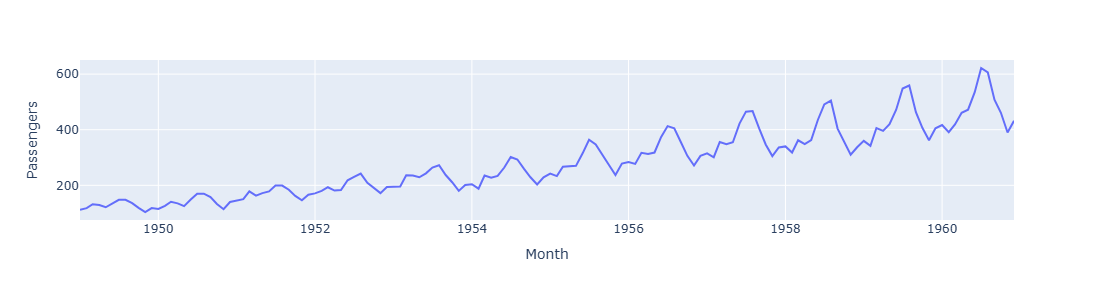

In [7]:
#Using Plotly Express
fig=px.line(
    df,
    x=df.index,
    y=df["Passengers"],
    labels={"Month":"Month","Passengers":"Passengers"}
)
fig.update_layout(
    width=1000,
    height=300
)
fig.show()

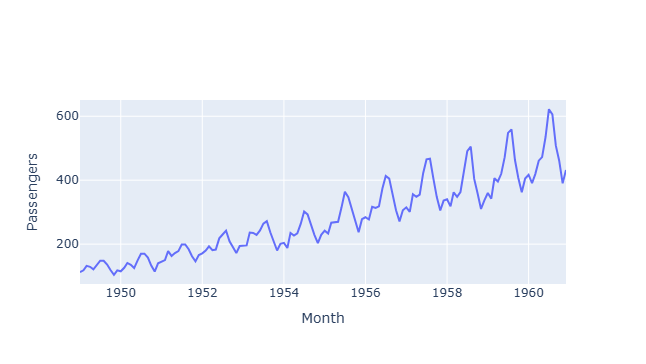

In [8]:
# Using Graph Objects
import plotly.graph_objects as go 
fig=go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Passengers"],
        mode="lines",
        name="Passengers"
    ))
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Passengers",
    width=1000,
    height=350)
fig.show()

In [9]:
monthly_avg=df.groupby(df.index.month)["Passengers"].mean()
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

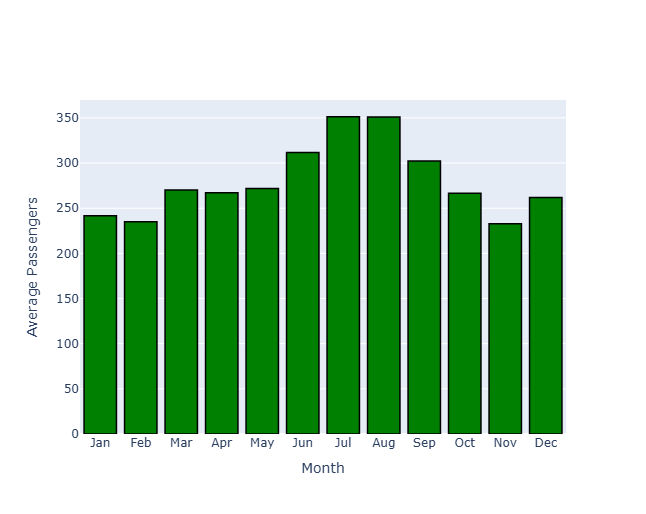

In [10]:
import plotly.graph_objects as go
fig=go.Figure()
fig.add_trace(go.Bar(
    x=month_names,
    y=monthly_avg.values,
    marker_color="green",
    marker_line_color="black",
    marker_line_width=1.5))
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Average Passengers",
    width=1000,
    height=500
)
fig.show()

In [11]:
df_diff=df[["Passengers"]].diff().dropna()

In [12]:
df_diff.head()

,Passengers
Month,
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0
1949-06-01,14.0


In [13]:
# Finding the d value
from statsmodels.tsa.stattools import adfuller

In [14]:
res=adfuller(df_diff["Passengers"])
print("Adf Statatics:",res[0])
print("P-Value:",res[1])

Adf Statatics: -2.8292668241699994
P-Value: 0.0542132902838255


In [15]:
df_diff2=df[["Passengers"]].diff(2).dropna()

In [16]:
res=adfuller(df_diff2["Passengers"])
print("Adf Statatics:",res[0])
print("P-Value:",res[1])

## D Value->Difference value is 2 

Adf Statatics: -2.9616951355554244
P-Value: 0.03862975767698839


In [17]:
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf

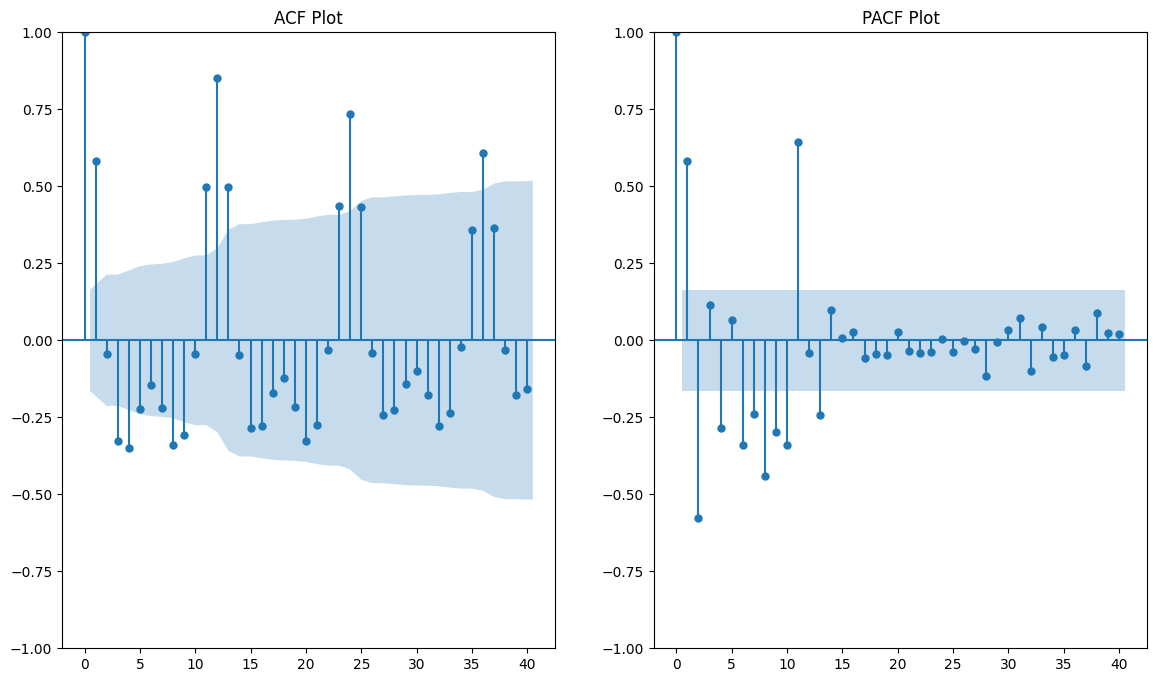

In [18]:
fig,axes=plt.subplots(1,2,figsize=(14,8))
plot_acf(df_diff2["Passengers"],lags=40,ax=axes[0])
axes[0].set_title("ACF Plot")
plot_pacf(df_diff2["Passengers"],lags=40,ax=axes[1])
axes[1].set_title("PACF Plot")
plt.show()

In [19]:
#Training Data-1949-1954
#Testing data-1955-1960
train=df.loc["1949":"1954"]
test=df.loc["1955":"1960"]

In [20]:
train

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1954-08-01,293
1954-09-01,259
1954-10-01,229


In [21]:
test

,Passengers
Month,
1955-01-01,242
1955-02-01,233
1955-03-01,267
1955-04-01,269
1955-05-01,270
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [22]:
train.shape

(72, 1)

In [23]:
test.shape

(72, 1)

In [48]:
df = df.asfreq("MS")

In [49]:
# Arima Model
from statsmodels.tsa.arima.model import ARIMA

In [59]:
model=ARIMA(train["Passengers"],order=(1,1,1))
model_arima=model.fit()
print(model_arima.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                   72
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -307.748
Date:                Tue, 03 Mar 2026   AIC                            621.496
Time:                        12:14:21   BIC                            628.284
Sample:                    01-01-1949   HQIC                           624.195
                         - 12-01-1954                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7168      0.156     -4.599      0.000      -1.022      -0.411
ma.L1          0.9160      0.083     11.016      0.000       0.753       1.079
sigma2       338.7664     69.992      4.840      0.0

In [60]:
arima_forecast=model_arima.forecast(steps=len(test))
print(arima_forecast)

1955-01-01    233.353859
1955-02-01    230.232913
1955-03-01    232.470079
1955-04-01    230.866426
1955-05-01    232.015961
                 ...    
1960-08-01    231.535997
1960-09-01    231.535997
1960-10-01    231.535997
1960-11-01    231.535997
1960-12-01    231.535997
Freq: MS, Name: predicted_mean, Length: 72, dtype: float64


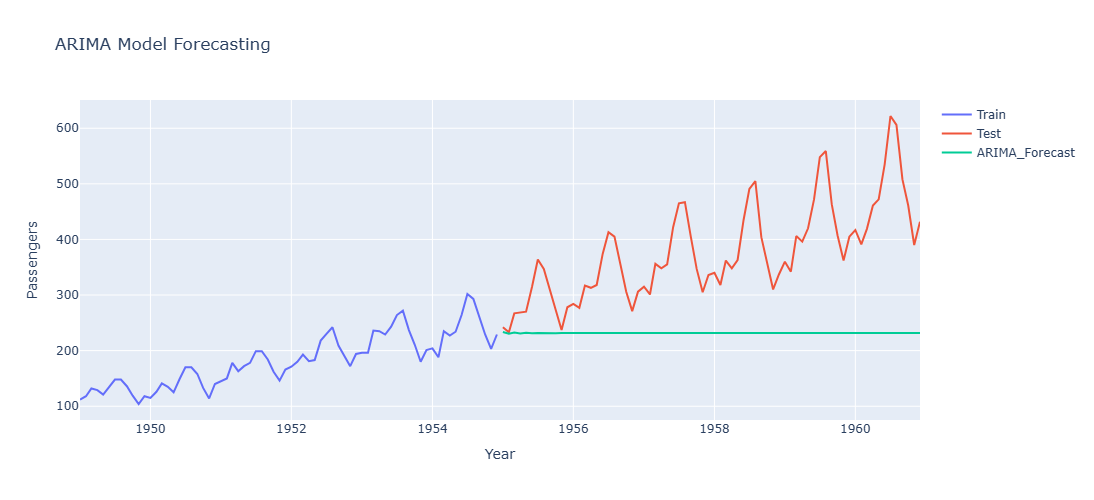

In [61]:
## Ploting arima
fig=go.Figure()
fig.add_trace(go.Scatter(
    x=train.index,
    y=train["Passengers"],
    mode="lines",
    name="Train"))
fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Test"))
fig.add_trace(go.Scatter(
    x=test.index,
    y=arima_forecast,
    mode="lines",
    name="ARIMA_Forecast"))
fig.update_layout(
    title="ARIMA Model Forecasting",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1000,
    height=500)
fig.show()

In [62]:
#SARIMA Model
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [63]:
model=SARIMAX(
    train["Passengers"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)
model_sarima=model.fit()
print(model_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                   72
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -214.656
Date:                            Tue, 03 Mar 2026   AIC                            439.312
Time:                                    12:14:44   BIC                            449.700
Sample:                                01-01-1949   HQIC                           443.367
                                     - 12-01-1954                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6878      0.298     -2.309      0.021      -1.272      -0.104
ma.L1          0.4319      0.331   

In [64]:
sarima_forecast=model_sarima.forecast(len(test))
print(sarima_forecast)

1955-01-01    231.013779
1955-02-01    220.850443
1955-03-01    266.748434
1955-04-01    262.190821
1955-05-01    263.729565
                 ...    
1960-08-01    423.907403
1960-09-01    389.677264
1960-10-01    360.333936
1960-11-01    332.678248
1960-12-01    357.413570
Freq: MS, Name: predicted_mean, Length: 72, dtype: float64


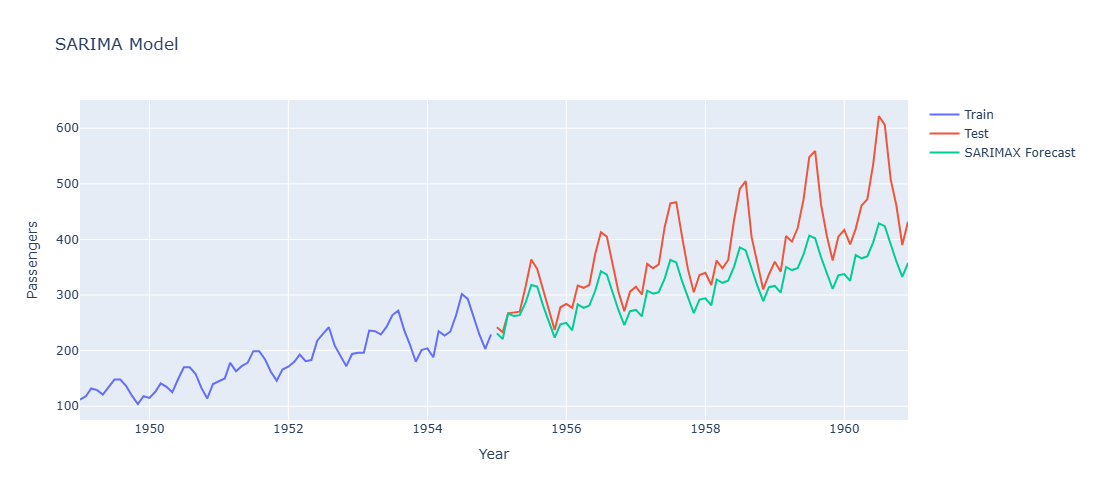

In [66]:
##Ploting SARIMAX
fig=go.Figure()
fig.add_trace(go.Scatter(
    x=train.index,
    y=train["Passengers"],
    mode="lines",
    name="Train"
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Test"
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=sarima_forecast,
    mode="lines",
    name="SARIMAX Forecast"))
fig.update_layout(
    title="SARIMA Model",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1000,
    height=500)
fig.show()

In [67]:
##Prophet Model
from prophet import Prophet
train_prophet=train.reset_index()
train_prophet.columns=["ds","y"]

In [68]:
prophet_model=Prophet(
    seasonality_mode='multiplicative',  
    yearly_seasonality=True,
    weekly_seasonality=False,    
    daily_seasonality=False,     
    changepoint_prior_scale=0.05,  
    seasonality_prior_scale=10     
)


In [69]:
prophet_model.fit(train_prophet)

12:15:43 - cmdstanpy - INFO - Chain [1] start processing
12:15:45 - cmdstanpy - INFO - Chain [1] done processing


In [70]:
future = prophet_model.make_future_dataframe(periods=len(test), freq="MS")
prophet_forecast = prophet_model.predict(future)

In [71]:
print(prophet_forecast)

            ds       trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
0   1949-01-01  119.892146  100.605631  116.761150   119.892146   119.892146   
1   1949-02-01  121.052741   99.252359  115.290877   121.052741   121.052741   
2   1949-03-01  122.101021  119.668538  135.462473   122.101021   122.101021   
3   1949-04-01  123.261616  115.310768  131.631867   123.261616   123.261616   
4   1949-05-01  124.384773  114.286141  130.308843   124.384773   124.384773   
..         ...         ...         ...         ...          ...          ...   
139 1960-08-01  364.359089  406.047714  472.614563   337.282147   390.569709   
140 1960-09-01  366.050970  348.303860  405.332072   338.338150   393.114743   
141 1960-10-01  367.688274  311.436374  366.545842   339.434101   395.429229   
142 1960-11-01  369.380155  273.222975  321.198744   340.475495   397.955973   
143 1960-12-01  371.017458  307.141710  361.561407   341.462917   400.299973   

     multiplicative_terms  multiplicati

In [72]:
forecast_test = prophet_forecast.tail(len(test))

In [73]:
forecast_test

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
72,1955-01-01,253.077004,221.035073,236.726895,253.052908,253.095307,-0.096636,-0.096636,-0.096636,-0.096636,-0.096636,-0.096636,0.0,0.0,0.0,228.620697
73,1955-02-01,254.768885,222.973646,238.883120,254.678953,254.845096,-0.091573,-0.091573,-0.091573,-0.091573,-0.091573,-0.091573,0.0,0.0,0.0,231.438829
74,1955-03-01,256.297035,258.703423,275.259562,256.116349,256.467794,0.041894,0.041894,0.041894,0.041894,0.041894,0.041894,0.0,0.0,0.0,267.034303
75,1955-04-01,257.988916,244.833255,260.721966,257.699264,258.290192,-0.019095,-0.019095,-0.019095,-0.019095,-0.019095,-0.019095,0.0,0.0,0.0,253.062672
76,1955-05-01,259.626220,251.299458,268.316282,259.182009,260.064654,0.001158,0.001158,0.001158,0.001158,0.001158,0.001158,0.0,0.0,0.0,259.926944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,1960-08-01,364.359089,406.047714,472.614563,337.282147,390.569709,0.205812,0.205812,0.205812,0.205812,0.205812,0.205812,0.0,0.0,0.0,439.348637
140,1960-09-01,366.050970,348.303860,405.332072,338.338150,393.114743,0.030753,0.030753,0.030753,0.030753,0.030753,0.030753,0.0,0.0,0.0,377.308008
141,1960-10-01,367.688274,311.436374,366.545842,339.434101,395.429229,-0.075322,-0.075322,-0.075322,-0.075322,-0.075322,-0.075322,0.0,0.0,0.0,339.993147
142,1960-11-01,369.380155,273.222975,321.198744,340.475495,397.955973,-0.193087,-0.193087,-0.193087,-0.193087,-0.193087,-0.193087,0.0,0.0,0.0,298.057546


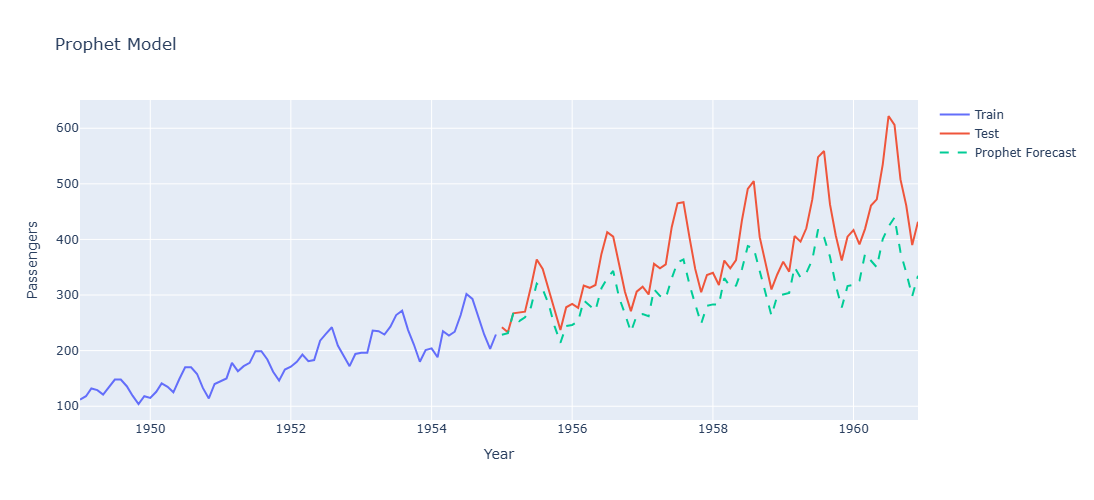

In [74]:
fig=go.Figure()
fig.add_trace(go.Scatter(
    x=train.index,
    y=train["Passengers"],
    mode="lines",
    name="Train"))
fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Test"
))
fig.add_trace(go.Scatter(
    x=forecast_test["ds"],
    y=forecast_test["yhat"],
    mode="lines",
    name="Prophet Forecast",
    line=dict(dash="dash"))
             )
fig.update_layout(title="Prophet Model",
                  xaxis_title="Year",
                  yaxis_title="Passengers",
                  width=1000,
                  height=500)
fig.show()

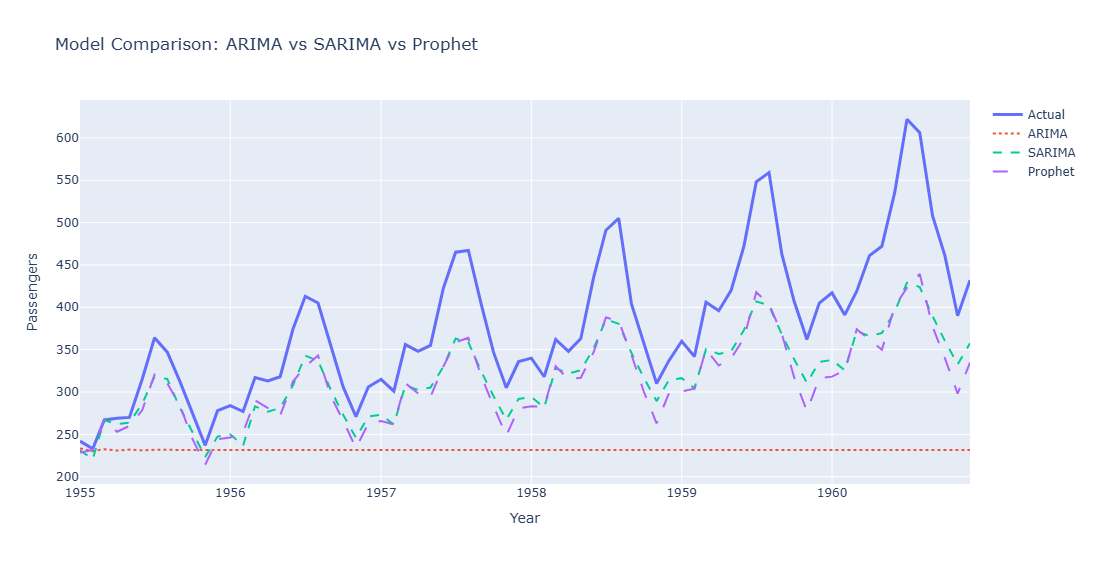

In [75]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Actual",
    line=dict(width=3)
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=arima_forecast,
    mode="lines",
    name="ARIMA",
    line=dict(dash="dot")
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=sarima_forecast,
    mode="lines",
    name="SARIMA",
    line=dict(dash="dash")
))

fig.add_trace(go.Scatter(
    x=test.index,
    y=forecast_test["yhat"],
    mode="lines",
    name="Prophet",
    line=dict(dash="longdash")
))

fig.update_layout(
    title="Model Comparison: ARIMA vs SARIMA vs Prophet",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1100,
    height=550
)

fig.show()

In [76]:
comparsion_df=pd.DataFrame({
    "Date":test.index,
    "Actual":test["Passengers"].values,
    "ARIMA":arima_forecast,
    "SARIMA":sarima_forecast,
    "Prophet":forecast_test["yhat"].values
})
comparsion_df.set_index("Date",inplace=True)


In [77]:
comparsion_df

,Actual,ARIMA,SARIMA,Prophet
Date,,,,
1955-01-01,242,233.353859,231.013779,228.620697
1955-02-01,233,230.232913,220.850443,231.438829
1955-03-01,267,232.470079,266.748434,267.034303
1955-04-01,269,230.866426,262.190821,253.062672
1955-05-01,270,232.015961,263.729565,259.926944
...,...,...,...,...
1960-08-01,606,231.535997,423.907403,439.348637
1960-09-01,508,231.535997,389.677264,377.308008
1960-10-01,461,231.535997,360.333936,339.993147


In [88]:
comparsion_df.to_csv("model_comparison.csv")

In [78]:
##Holt-Winter Model-Givin Importance to recent value and giving less impottance to previous values and weights are decreasing exponentially
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [79]:
train = train.asfreq("MS")

In [80]:
hw_model=ExponentialSmoothing(
    train["Passengers"],
    trend="add",
    seasonal="mul",
    seasonal_periods=12
).fit()

In [81]:
hw_forecast=hw_model.forecast(len(test))

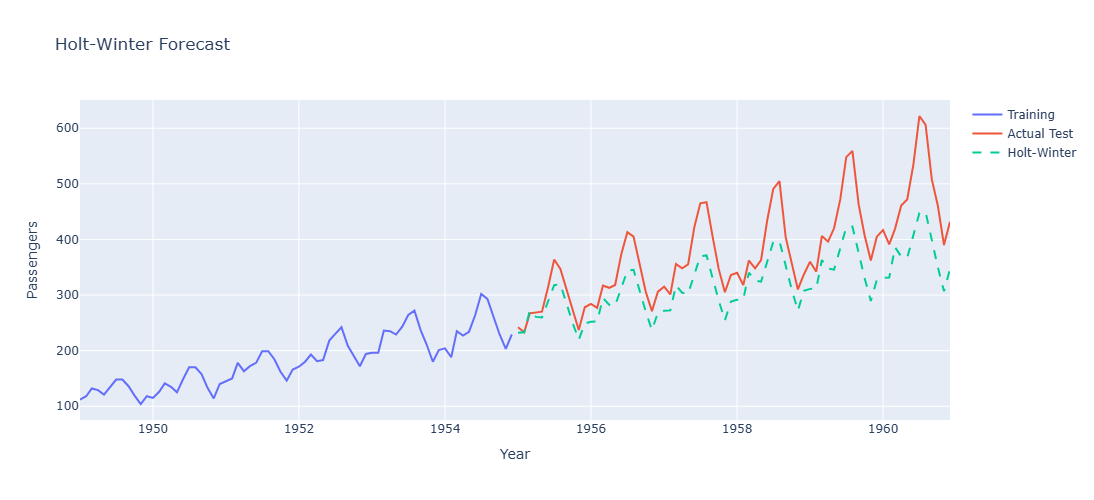

In [82]:
fig=go.Figure()
fig.add_trace(
    go.Scatter(
        x=train.index,
        y=train["Passengers"],
        mode="lines",
        name="Training"
    ))
fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Actual Test"
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=hw_forecast,
    mode="lines",
    name="Holt-Winter",
    line=dict(dash="dash")
))
fig.update_layout(
    title="Holt-Winter Forecast",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1000,
    height=500)
fig.show()

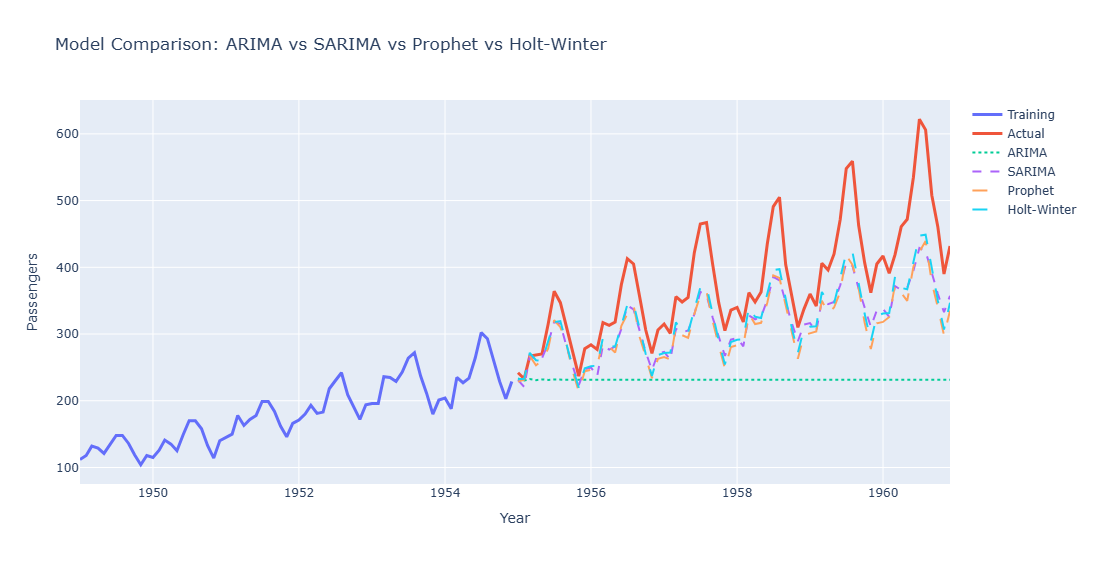

In [83]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=train.index,
    y=train["Passengers"],
    mode="lines",
    name="Training",
    line=dict(width=3)
))

fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Actual",
    line=dict(width=3)
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=arima_forecast,
    mode="lines",
    name="ARIMA",
    line=dict(dash="dot")
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=sarima_forecast,
    mode="lines",
    name="SARIMA",
    line=dict(dash="dash")
))

fig.add_trace(go.Scatter(
    x=test.index,
    y=forecast_test["yhat"],
    mode="lines",
    name="Prophet",
    line=dict(dash="longdash")
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=hw_forecast,
    mode="lines",
    name="Holt-Winter",
    line=dict(dash="longdash")
))

fig.update_layout(
    title="Model Comparison: ARIMA vs SARIMA vs Prophet vs Holt-Winter",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1100,
    height=550
)

fig.show()

In [84]:
train_log = np.log(train["Passengers"])

In [93]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
ets_model=ETSModel(
    train["Passengers"],
    error="add",
    trend="add",
    seasonal="add",
    seasonal_periods=12)

In [94]:
ets_fit = ets_model.fit()

In [95]:
ets_forecast = ets_fit.forecast(steps=len(test))


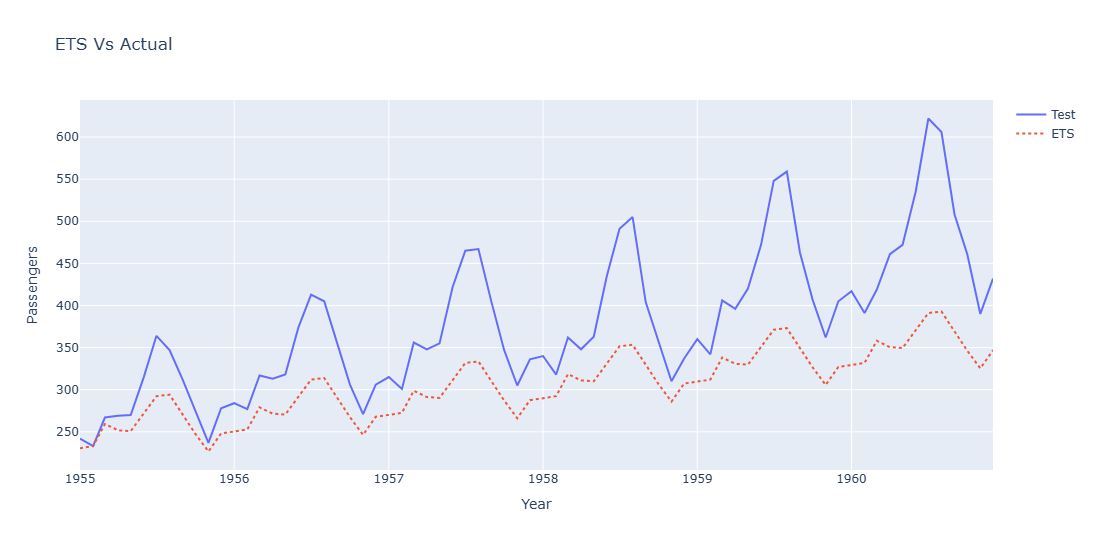

In [96]:
fig=go.Figure()
fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Test"))
fig.add_trace(
    go.Scatter(
        x=test.index,
        y=ets_forecast,
        mode="lines",
        name="ETS",
        line=dict(dash="dot")))
fig.update_layout(
    title="ETS Vs Actual",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1000,
    height=550)